## Step 1

- Import Dataset
- Import Data
- Quick data checking

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")
pd.set_option("display.max_columns", None)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [5]:
data_path = "../data/ph_weather_2020_Mar_2025.csv"

In [6]:
df = pd.read_csv(data_path)

In [7]:
df.head()

,city_name,datetime,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
0,Alaminos,1/1/2020,1.0,32.4,23.1,26.9,35.6,25.1,30.1,2020-01-01T06:27,2020-01-01T17:38,40263.84,36299.32,0.0,0.0,0.0,0,18.0,33.5,82.0,18.68,4.37
1,Alaminos,1/2/2020,1.0,32.7,25.4,27.8,35.6,27.1,30.5,2020-01-02T06:28,2020-01-02T17:39,40277.32,36381.88,0.0,0.0,0.0,0,18.0,35.6,91.0,18.57,4.85
2,Alaminos,1/3/2020,3.0,31.3,23.2,26.5,33.3,25.2,28.7,2020-01-03T06:28,2020-01-03T17:40,40292.00,36385.75,0.0,0.0,0.0,0,17.6,33.8,103.0,18.02,4.47
3,Alaminos,1/4/2020,0.0,30.2,21.6,25.5,32.4,22.8,27.7,2020-01-04T06:28,2020-01-04T17:40,40307.85,36506.23,0.0,0.0,0.0,0,15.5,30.2,73.0,19.51,4.40
4,Alaminos,1/5/2020,1.0,31.9,23.8,26.7,33.1,25.3,28.6,2020-01-05T06:29,2020-01-05T17:41,40324.83,36564.63,0.0,0.0,0.0,0,19.8,38.9,96.0,19.56,4.95


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268473 entries, 0 to 268472
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   city_name                    268473 non-null  object 
 1   datetime                     268473 non-null  object 
 2   weather_code                 268336 non-null  float64
 3   temperature_2m_max           268336 non-null  float64
 4   temperature_2m_min           268336 non-null  float64
 5   temperature_2m_mean          268062 non-null  float64
 6   apparent_temperature_max     268336 non-null  float64
 7   apparent_temperature_min     268336 non-null  float64
 8   apparent_temperature_mean    268062 non-null  float64
 9   sunrise                      268473 non-null  object 
 10  sunset                       268473 non-null  object 
 11  daylight_duration            268473 non-null  float64
 12  sunshine_duration            268062 non-null  float64
 13 

In [9]:
df.isnull().sum()

city_name                        0
datetime                         0
weather_code                   137
temperature_2m_max             137
temperature_2m_min             137
temperature_2m_mean            411
apparent_temperature_max       137
apparent_temperature_min       137
apparent_temperature_mean      411
sunrise                          0
sunset                           0
daylight_duration                0
sunshine_duration              411
precipitation_sum              411
rain_sum                       411
snowfall_sum                   411
precipitation_hours              0
wind_speed_10m_max             137
wind_gusts_10m_max             137
wind_direction_10m_dominant    411
shortwave_radiation_sum        411
et0_fao_evapotranspiration     411
dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
weather_code,268336.0,51.705410,17.962295,0.00,51.000,55.00,63.0000,65.00
temperature_2m_max,268336.0,30.103307,2.301740,17.40,28.800,30.10,31.3000,40.70
temperature_2m_min,268336.0,24.185796,1.696096,7.60,23.500,24.50,25.2000,29.50
temperature_2m_mean,268062.0,26.746117,1.691836,12.70,26.000,26.90,27.7000,33.00
apparent_temperature_max,268336.0,35.453908,3.199264,16.20,33.600,35.80,37.7000,45.80
apparent_temperature_min,268336.0,28.376557,2.611156,5.30,27.300,28.90,30.1000,35.30
apparent_temperature_mean,268062.0,31.308698,2.549543,11.30,30.100,31.80,33.0000,37.80
daylight_duration,268473.0,43607.036307,1834.021202,39736.27,42083.720,43559.66,45141.3700,47591.09
sunshine_duration,268062.0,33536.898478,10182.251735,0.00,30465.675,37494.80,40145.5275,43853.66
precipitation_sum,268062.0,7.399829,12.297992,0.00,0.700,3.20,9.5000,440.50


## Step 2: Data Cleaning

In [11]:
df_pasig = df[df['city_name'].str.lower() == 'pasig' ].copy()
df_pasig.head()

,city_name,datetime,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration
149022,Pasig,1/1/2020,55.0,30.9,22.8,26.3,34.1,26.8,30.4,2020-01-01T06:20,2020-01-01T17:37,40601.74,36354.61,3.0,3.0,0.0,11,18.5,56.2,54.0,16.80,3.60
149023,Pasig,1/2/2020,51.0,31.1,22.9,26.7,34.3,27.4,30.5,2020-01-02T06:20,2020-01-02T17:37,40613.83,36596.39,0.1,0.1,0.0,1,15.6,51.1,65.0,19.18,4.24
149024,Pasig,1/3/2020,1.0,30.9,21.8,25.8,32.6,25.2,28.5,2020-01-03T06:21,2020-01-03T17:38,40626.99,36371.84,0.0,0.0,0.0,0,17.6,39.2,63.0,19.77,4.38
149025,Pasig,1/4/2020,2.0,31.1,20.8,25.5,33.4,23.3,28.2,2020-01-04T06:21,2020-01-04T17:38,40641.20,36672.16,0.0,0.0,0.0,0,16.3,37.1,52.0,18.11,4.04
149026,Pasig,1/5/2020,1.0,30.4,22.7,26.1,31.1,26.7,28.5,2020-01-05T06:21,2020-01-05T17:39,40656.43,36598.13,0.0,0.0,0.0,0,21.3,46.4,74.0,19.31,4.50


In [12]:
df_pasig['datetime'] = pd.to_datetime(df_pasig['datetime'], errors = 'coerce')
df_pasig = df_pasig.sort_values(by='datetime')

In [13]:
print("Date range:", df_pasig['datetime'].min(), "to", df_pasig['datetime'].max())

Date range: 2020-01-01 00:00:00 to 2025-03-31 00:00:00


In [14]:
missing = df_pasig.isnull().sum()
print(missing[missing > 0] )

weather_code                   1
temperature_2m_max             1
temperature_2m_min             1
temperature_2m_mean            3
apparent_temperature_max       1
apparent_temperature_min       1
apparent_temperature_mean      3
sunshine_duration              3
precipitation_sum              3
rain_sum                       3
snowfall_sum                   3
wind_speed_10m_max             1
wind_gusts_10m_max             1
wind_direction_10m_dominant    3
shortwave_radiation_sum        3
et0_fao_evapotranspiration     3
dtype: int64


In [15]:
df_pasig = df_pasig.dropna(subset=['datetime'])

In [16]:
numeric_cols = df_pasig.select_dtypes(include = ['float64', 'int64']).columns
df_pasig[numeric_cols] = df_pasig[numeric_cols].fillna(df_pasig[numeric_cols].mean())

In [17]:
df_pasig['year'] = df_pasig['datetime'].dt.year
df_pasig['month'] = df_pasig['datetime'].dt.month
df_pasig['day'] = df_pasig['datetime'].dt.day

df_pasig[['datetime', 'year', 'month', 'day']].head(10)

,datetime,year,month,day
149022,2020-01-01,2020,1,1
149023,2020-01-02,2020,1,2
149024,2020-01-03,2020,1,3
149025,2020-01-04,2020,1,4
149026,2020-01-05,2020,1,5
149027,2020-01-06,2020,1,6
149028,2020-01-07,2020,1,7
149029,2020-01-08,2020,1,8
149030,2020-01-09,2020,1,9
149031,2020-01-10,2020,1,10


In [18]:
df_pasig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1917 entries, 149022 to 250688
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   city_name                    1917 non-null   object        
 1   datetime                     1917 non-null   datetime64[ns]
 2   weather_code                 1917 non-null   float64       
 3   temperature_2m_max           1917 non-null   float64       
 4   temperature_2m_min           1917 non-null   float64       
 5   temperature_2m_mean          1917 non-null   float64       
 6   apparent_temperature_max     1917 non-null   float64       
 7   apparent_temperature_min     1917 non-null   float64       
 8   apparent_temperature_mean    1917 non-null   float64       
 9   sunrise                      1917 non-null   object        
 10  sunset                       1917 non-null   object        
 11  daylight_duration            1917 non-nul

In [19]:
df_pasig.isnull().sum()

city_name                      0
datetime                       0
weather_code                   0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
apparent_temperature_max       0
apparent_temperature_min       0
apparent_temperature_mean      0
sunrise                        0
sunset                         0
daylight_duration              0
sunshine_duration              0
precipitation_sum              0
rain_sum                       0
snowfall_sum                   0
precipitation_hours            0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
et0_fao_evapotranspiration     0
year                           0
month                          0
day                            0
dtype: int64

In [20]:
df_pasig.head(10)

,city_name,datetime,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,year,month,day
149022,Pasig,2020-01-01,55.0,30.9,22.8,26.3,34.1,26.8,30.4,2020-01-01T06:20,2020-01-01T17:37,40601.74,36354.61,3.0,3.0,0.0,11,18.5,56.2,54.0,16.80,3.60,2020,1,1
149023,Pasig,2020-01-02,51.0,31.1,22.9,26.7,34.3,27.4,30.5,2020-01-02T06:20,2020-01-02T17:37,40613.83,36596.39,0.1,0.1,0.0,1,15.6,51.1,65.0,19.18,4.24,2020,1,2
149024,Pasig,2020-01-03,1.0,30.9,21.8,25.8,32.6,25.2,28.5,2020-01-03T06:21,2020-01-03T17:38,40626.99,36371.84,0.0,0.0,0.0,0,17.6,39.2,63.0,19.77,4.38,2020,1,3
149025,Pasig,2020-01-04,2.0,31.1,20.8,25.5,33.4,23.3,28.2,2020-01-04T06:21,2020-01-04T17:38,40641.20,36672.16,0.0,0.0,0.0,0,16.3,37.1,52.0,18.11,4.04,2020,1,4
149026,Pasig,2020-01-05,1.0,30.4,22.7,26.1,31.1,26.7,28.5,2020-01-05T06:21,2020-01-05T17:39,40656.43,36598.13,0.0,0.0,0.0,0,21.3,46.4,74.0,19.31,4.50,2020,1,5
149027,Pasig,2020-01-06,0.0,31.4,21.7,26.0,33.3,24.8,28.4,2020-01-06T06:22,2020-01-06T17:40,40672.65,36691.47,0.0,0.0,0.0,0,18.5,41.8,74.0,19.89,4.61,2020,1,6
149028,Pasig,2020-01-07,63.0,32.0,21.6,26.3,35.6,24.6,29.5,2020-01-07T06:22,2020-01-07T17:40,40689.86,36592.36,12.1,12.1,0.0,6,18.0,44.6,91.0,17.06,3.90,2020,1,7
149029,Pasig,2020-01-08,51.0,30.8,23.4,26.6,34.2,28.3,30.6,2020-01-08T06:22,2020-01-08T17:41,40708.00,36531.55,0.9,0.9,0.0,6,14.1,32.4,99.0,17.18,3.75,2020,1,8
149030,Pasig,2020-01-09,3.0,31.1,21.9,25.8,33.4,26.1,29.0,2020-01-09T06:23,2020-01-09T17:41,40727.08,36871.41,0.0,0.0,0.0,0,18.1,39.2,95.0,17.86,4.03,2020,1,9
149031,Pasig,2020-01-10,53.0,30.1,21.5,25.4,33.0,24.7,28.4,2020-01-10T06:23,2020-01-10T17:42,40747.06,36753.77,1.7,1.7,0.0,4,15.9,34.6,88.0,16.91,3.77,2020,1,10


In [21]:
df_pasig.tail(10)

,city_name,datetime,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,year,month,day
250679,Pasig,2025-03-22,3.0,32.8,24.1,27.400000,34.8,26.7,29.400000,2025-03-22T05:58,2025-03-22T18:06,43703.12,37943.210000,0.000000,0.000000,0.0,0,12.8,34.2,93.000000,19.480000,4.80000,2025,3,22
250680,Pasig,2025-03-23,3.0,32.5,22.8,27.200000,34.0,26.1,29.700000,2025-03-23T05:57,2025-03-23T18:06,43752.62,37600.220000,0.000000,0.000000,0.0,0,12.1,33.8,87.000000,17.140000,4.28000,2025,3,23
250681,Pasig,2025-03-24,51.0,33.4,23.7,28.600000,37.5,27.1,32.000000,2025-03-24T05:56,2025-03-24T18:06,43801.96,40976.950000,1.100000,1.100000,0.0,6,7.5,24.5,170.000000,19.510000,4.44000,2025,3,24
250682,Pasig,2025-03-25,51.0,35.8,26.0,29.900000,40.2,29.8,33.400000,2025-03-25T05:56,2025-03-25T18:07,43851.11,40533.680000,0.100000,0.100000,0.0,1,15.4,42.5,121.000000,23.420000,5.84000,2025,3,25
250683,Pasig,2025-03-26,51.0,36.5,25.0,30.100000,40.0,29.3,33.600000,2025-03-26T05:55,2025-03-26T18:07,43900.04,41411.620000,0.400000,0.400000,0.0,2,18.3,47.5,119.000000,22.900000,5.80000,2025,3,26
250684,Pasig,2025-03-27,53.0,34.9,26.7,30.200000,39.4,30.5,34.000000,2025-03-27T05:54,2025-03-27T18:07,43948.71,40314.160000,0.800000,0.800000,0.0,4,14.5,41.4,123.000000,21.840000,5.49000,2025,3,27
250685,Pasig,2025-03-28,65.0,36.4,27.0,29.900000,40.9,31.6,34.500000,2025-03-28T05:54,2025-03-28T18:07,43997.09,38761.530000,19.000000,19.000000,0.0,5,12.2,37.8,113.000000,21.860000,5.10000,2025,3,28
250686,Pasig,2025-03-29,53.0,30.8,25.5,27.400000,34.7,29.7,32.000000,2025-03-29T05:53,2025-03-29T18:07,44045.47,13136.710000,2.800000,2.800000,0.0,13,14.6,38.2,111.000000,11.430000,2.85000,2025,3,29
250687,Pasig,2025-03-30,53.0,32.9,25.3,28.300000,37.9,30.6,32.900000,2025-03-30T05:52,2025-03-30T18:07,44093.99,40988.090000,3.000000,3.000000,0.0,8,13.1,38.9,112.000000,20.880000,4.78000,2025,3,30
250688,Pasig,2025-03-31,3.0,28.0,25.0,27.310502,32.5,29.9,31.790805,2025-03-31T05:52,2025-03-31T18:07,44142.61,34727.144671,6.065674,6.065674,0.0,0,8.5,19.1,145.664054,18.709645,4.17187,2025,3,31


## Step 3: EDA

In [22]:
df_pasig.shape

(1917, 25)

In [23]:
list(df_pasig.columns)

['city_name',
 'datetime',
 'weather_code',
 'temperature_2m_max',
 'temperature_2m_min',
 'temperature_2m_mean',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'apparent_temperature_mean',
 'sunrise',
 'sunset',
 'daylight_duration',
 'sunshine_duration',
 'precipitation_sum',
 'rain_sum',
 'snowfall_sum',
 'precipitation_hours',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'year',
 'month',
 'day']

In [24]:
df_pasig.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,1917,2022-08-16 00:00:00.000000256,2020-01-01 00:00:00,2021-04-24 00:00:00,2022-08-16 00:00:00,2023-12-08 00:00:00,2025-03-31 00:00:00,NaN
weather_code,1917.0,48.712422,0.0,51.0,53.0,63.0,65.0,20.312287
temperature_2m_max,1917.0,31.358299,24.6,29.9,31.1,32.7,38.7,2.274488
temperature_2m_min,1917.0,24.164405,18.7,23.4,24.3,25.0,28.4,1.375705
temperature_2m_mean,1917.0,27.310502,22.8,26.4,27.2,28.1,32.5,1.448395
apparent_temperature_max,1917.0,36.181211,27.8,34.3,36.4,38.2,42.9,2.69281
apparent_temperature_min,1917.0,28.601096,19.7,27.5,29.1,30.0,33.6,2.134642
apparent_temperature_mean,1917.0,31.790805,24.2,30.6,32.1,33.1,36.6,1.99748
daylight_duration,1917.0,43607.634721,40543.74,41535.95,43546.62,45696.38,46763.21,2138.035821
sunshine_duration,1917.0,34727.144671,0.0,33000.18,38049.51,40988.09,43277.57,9710.965316


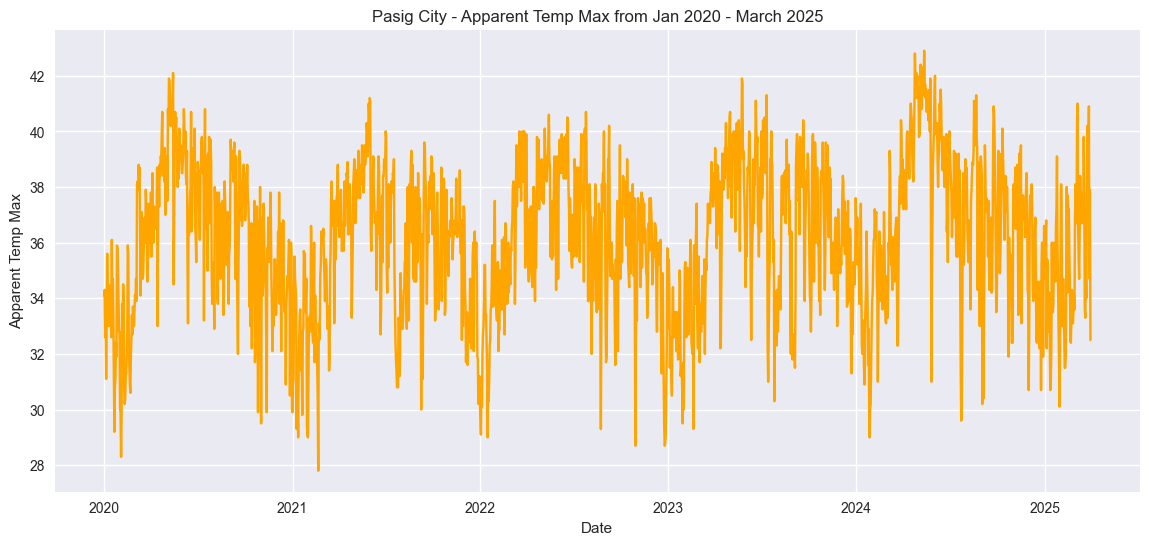

In [25]:
plt.figure(figsize = (14, 6))
plt.plot(df_pasig['datetime'],df_pasig['apparent_temperature_max'], color='orange')
plt.title("Pasig City - Apparent Temp Max from Jan 2020 - March 2025")
plt.xlabel("Date")
plt.ylabel("Apparent Temp Max")
plt.show()

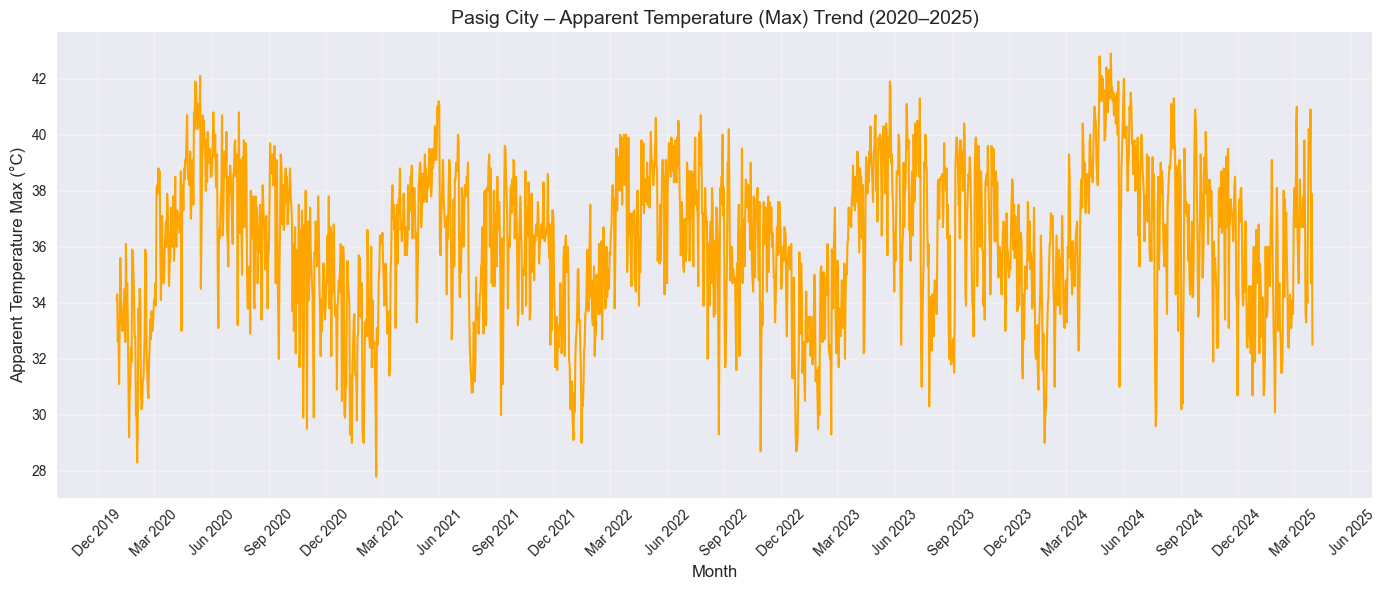

In [26]:
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))
plt.plot(df_pasig['datetime'], df_pasig['apparent_temperature_max'], color='orange', linewidth=1.5)

plt.title("Pasig City – Apparent Temperature (Max) Trend (2020–2025)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Apparent Temperature Max (°C)", fontsize=12)
plt.grid(True, alpha=0.3)

# Format x-axis to show month and year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # e.g., Jan 2020
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # show every 3 months
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

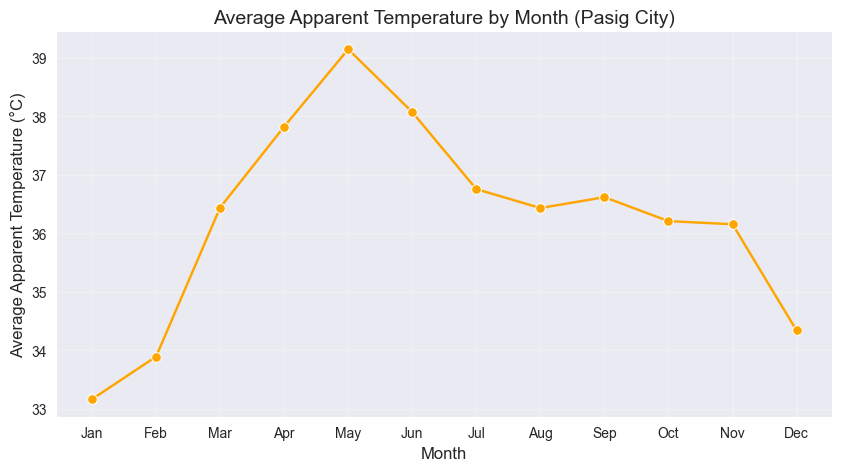

In [27]:
monthly_avg = df_pasig.groupby('month')['apparent_temperature_max'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', color='orange')

plt.title("Average Apparent Temperature by Month (Pasig City)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Apparent Temperature (°C)", fontsize=12)
plt.xticks(range(1,13), 
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.show()

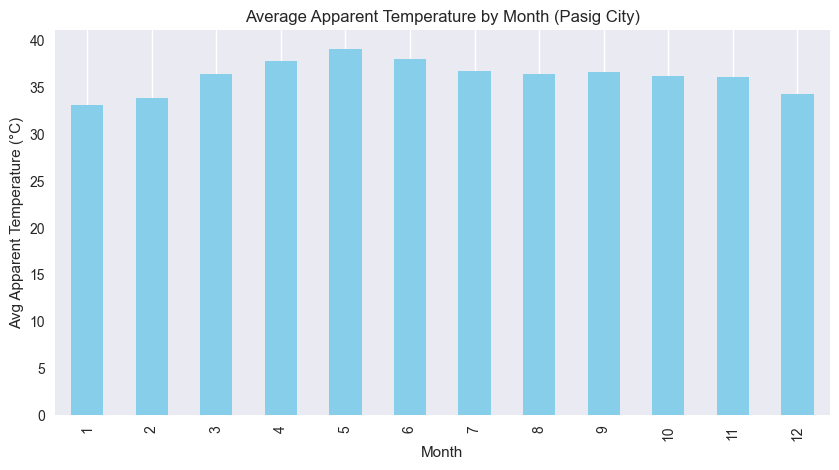

In [28]:
# Group by month
monthly_avg = df_pasig.groupby('month')['apparent_temperature_max'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar', color='skyblue')
plt.title("Average Apparent Temperature by Month (Pasig City)")
plt.xlabel("Month")
plt.ylabel("Avg Apparent Temperature (°C)")
plt.grid(axis='y')
plt.show()

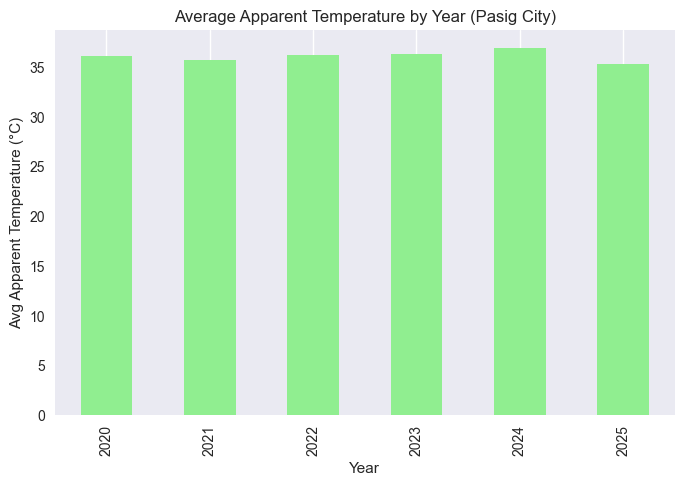

In [29]:
# Group by year
yearly_avg = df_pasig.groupby('year')['apparent_temperature_max'].mean()

plt.figure(figsize=(8,5))
yearly_avg.plot(kind='bar', color='lightgreen')
plt.title("Average Apparent Temperature by Year (Pasig City)")
plt.xlabel("Year")
plt.ylabel("Avg Apparent Temperature (°C)")
plt.grid(axis='y')
plt.show()

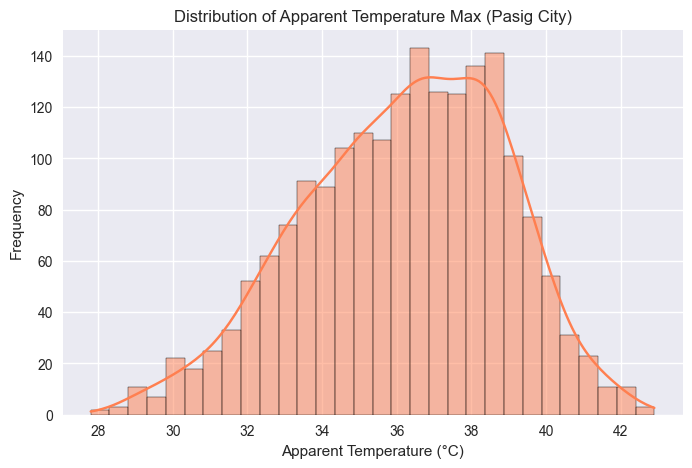

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df_pasig['apparent_temperature_max'], bins=30, kde=True, color='coral')
plt.title("Distribution of Apparent Temperature Max (Pasig City)")
plt.xlabel("Apparent Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

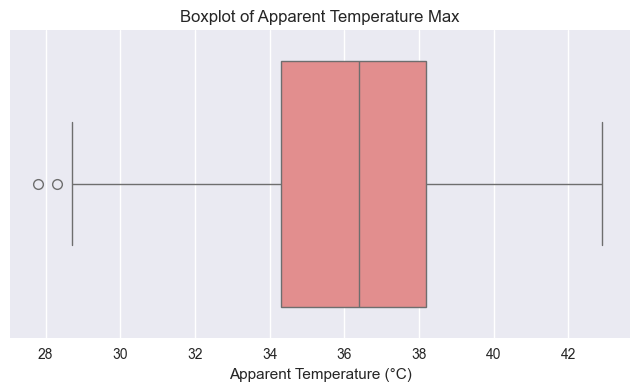

In [31]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_pasig['apparent_temperature_max'], color='lightcoral')
plt.title("Boxplot of Apparent Temperature Max")
plt.xlabel("Apparent Temperature (°C)")
plt.show()

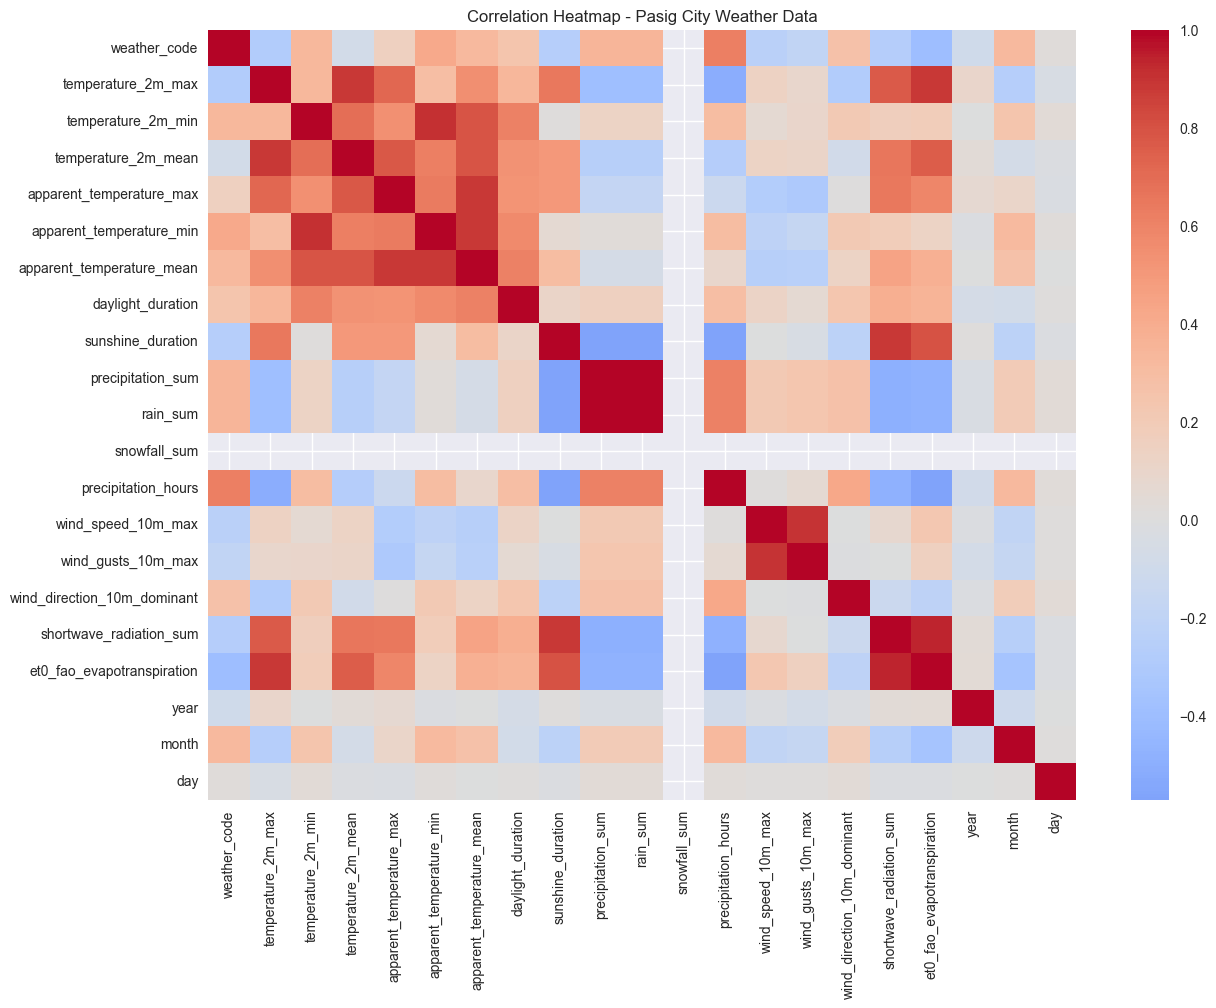

In [32]:

corr_matrix = df_pasig.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Pasig City Weather Data")
plt.show()

In [33]:
# Focused correlation with target
corr_target = corr_matrix['apparent_temperature_max'].sort_values(ascending=False)
print("Correlation with Apparent Temperature Max:\n")
print(corr_target)

Correlation with Apparent Temperature Max:

apparent_temperature_max       1.000000
apparent_temperature_mean      0.884659
temperature_2m_mean            0.773367
temperature_2m_max             0.721646
shortwave_radiation_sum        0.652754
apparent_temperature_min       0.632590
et0_fao_evapotranspiration     0.583894
temperature_2m_min             0.541793
daylight_duration              0.523968
sunshine_duration              0.505532
weather_code                   0.153468
month                          0.105820
year                           0.071169
wind_direction_10m_dominant    0.001768
day                           -0.030316
precipitation_hours           -0.125249
rain_sum                      -0.175281
precipitation_sum             -0.175281
wind_speed_10m_max            -0.272111
wind_gusts_10m_max            -0.303193
snowfall_sum                        NaN
Name: apparent_temperature_max, dtype: float64


## 4. Select Features and Save Clean Dataset for Modeling

In [34]:
selected_features = [
    'temperature_2m_mean',
    'temperature_2m_min',
    'shortwave_radiation_sum',
    'daylight_duration',
    'sunshine_duration',
    'et0_fao_evapotranspiration',
    'rain_sum',
    'precipitation_sum',
    'wind_speed_10m_max',
    'wind_gusts_10m_max',
    'month'
]

target = 'apparent_temperature_max'

In [35]:
df_model = df_pasig[selected_features + [target, 'datetime']].copy()

df_model.head()

,temperature_2m_mean,temperature_2m_min,shortwave_radiation_sum,daylight_duration,sunshine_duration,et0_fao_evapotranspiration,rain_sum,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,month,apparent_temperature_max,datetime
149022,26.3,22.8,16.80,40601.74,36354.61,3.60,3.0,3.0,18.5,56.2,1,34.1,2020-01-01
149023,26.7,22.9,19.18,40613.83,36596.39,4.24,0.1,0.1,15.6,51.1,1,34.3,2020-01-02
149024,25.8,21.8,19.77,40626.99,36371.84,4.38,0.0,0.0,17.6,39.2,1,32.6,2020-01-03
149025,25.5,20.8,18.11,40641.20,36672.16,4.04,0.0,0.0,16.3,37.1,1,33.4,2020-01-04
149026,26.1,22.7,19.31,40656.43,36598.13,4.50,0.0,0.0,21.3,46.4,1,31.1,2020-01-05


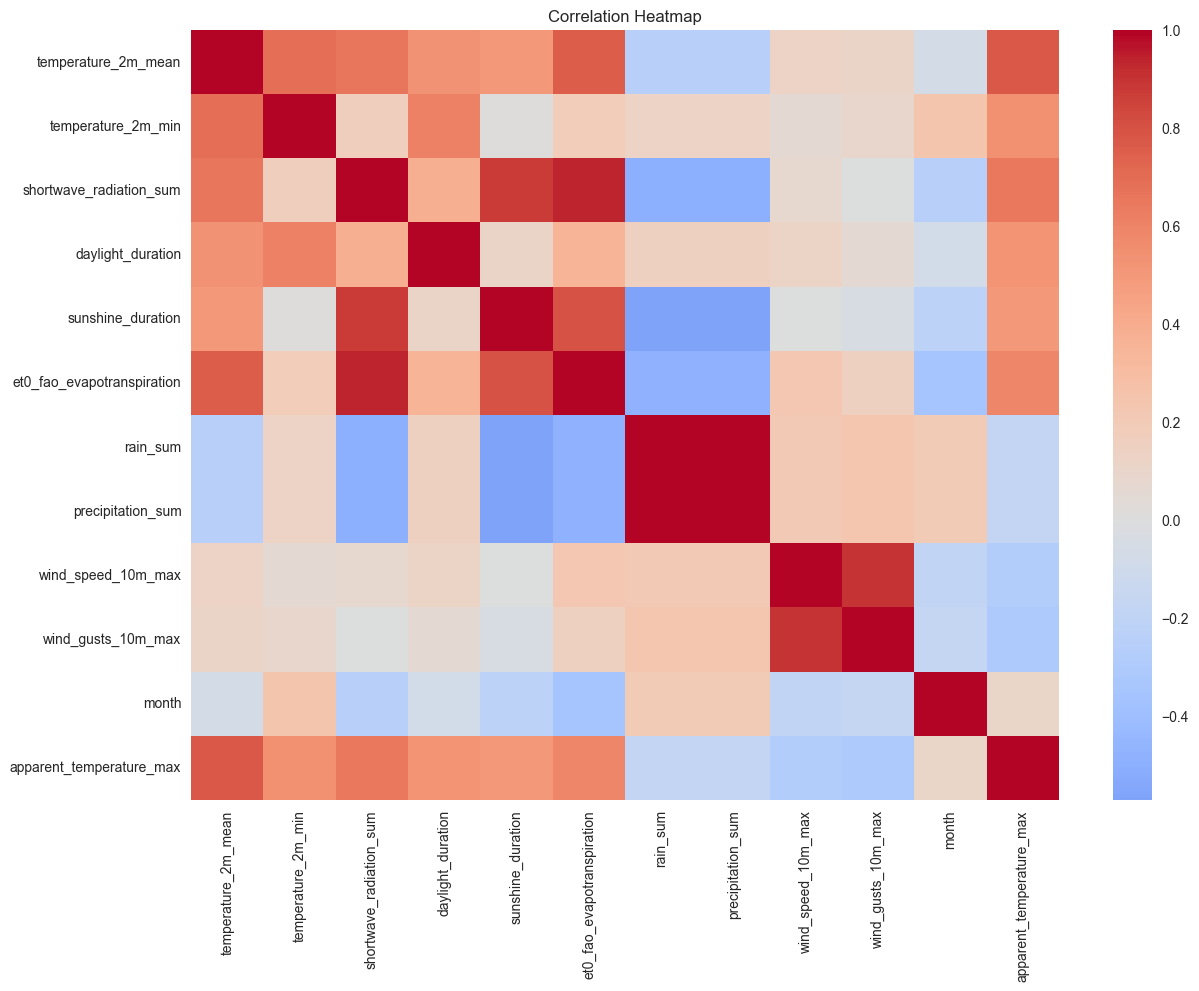

In [36]:
corr_matrix = df_model.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [38]:
# Focused correlation with target
corr_target = corr_matrix['apparent_temperature_max'].sort_values(ascending=False)
corr_target

apparent_temperature_max      1.000000
temperature_2m_mean           0.773367
shortwave_radiation_sum       0.652754
et0_fao_evapotranspiration    0.583894
temperature_2m_min            0.541793
daylight_duration             0.523968
sunshine_duration             0.505532
month                         0.105820
precipitation_sum            -0.175281
rain_sum                     -0.175281
wind_speed_10m_max           -0.272111
wind_gusts_10m_max           -0.303193
Name: apparent_temperature_max, dtype: float64

In [39]:
output_path = "../data/pasig_clean_for_model.csv"
df_model.to_csv(output_path, index=False)